<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/2_4_NonCoding_RNAs_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Non-Coding RNAs — miRNA, lncRNA, siRNA and Their Role in Disease

**Learning objectives**
- Distinguish miRNA / lncRNA / siRNA by their characteristic size and mechanism
- Simulate a small-RNA-seq read-length distribution and classify reads by ncRNA class
- Model lncRNA-mediated chromatin/transcriptional regulation (a simplified XIST/HOTAIR-style tethering mechanism)
- Analyze a simulated ncRNA expression dataset (cancer vs normal) to find candidate disease biomarkers
- Build a small ncRNA–mRNA regulatory network graph

**Background**

| ncRNA type | Typical size | Main mechanism |
|---|---|---|
| miRNA | ~21–23 nt | Post-transcriptional regulation (seed-based mRNA targeting → translational repression / decay) |
| siRNA | ~21–23 nt | Gene silencing via near-perfect mRNA target cleavage (RNAi) |
| lncRNA | >200 nt | Chromatin modification & transcriptional regulation (e.g. scaffolding chromatin-modifying complexes) |

Beyond normal regulation, ncRNAs are increasingly used as **cancer biomarkers**, studied as **drug targets**, and recognized as **controllers of larger regulatory networks** (competing endogenous RNA / ceRNA networks, chromatin regulatory hubs, etc).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(21)
plt.rcParams['figure.figsize'] = (8,4)
print("Environment ready.")


Environment ready.


## Part 1 — Classifying Small RNA-seq Reads by Size

A small-RNA-seq library from a cell typically contains a mixture of ncRNA species that can be told apart largely by their **length distribution** after adapter trimming. We'll simulate a realistic mixed library and classify reads.


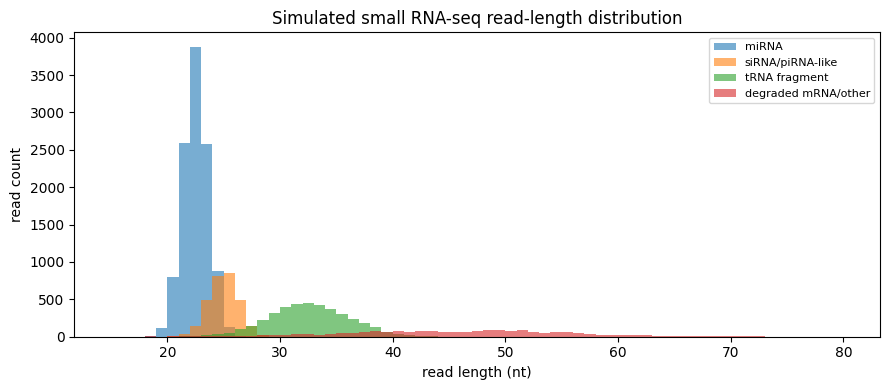

called_class
miRNA/siRNA-sized (21-23nt peak)    12316
other/degraded                       2217
tRNA-fragment-sized                  5467
dtype: int64


In [ ]:
n_reads = 20000
# proportions roughly inspired by typical small-RNA-seq compositions
species_params = {
    'miRNA':  dict(frac=0.55, mean=22, sd=1.1),
    'siRNA/piRNA-like': dict(frac=0.15, mean=24.5, sd=1.3),
    'tRNA fragment': dict(frac=0.20, mean=32, sd=3.5),
    'degraded mRNA/other': dict(frac=0.10, mean=45, sd=10),
}

rows = []
for name, p in species_params.items():
    n = int(n_reads * p['frac'])
    lengths = np.round(np.random.normal(p['mean'], p['sd'], n)).astype(int)
    lengths = np.clip(lengths, 15, 80)
    rows.append(pd.DataFrame({'length': lengths, 'true_class': name}))

reads = pd.concat(rows, ignore_index=True)

plt.figure(figsize=(9,4))
for name in species_params:
    subset = reads[reads['true_class']==name]
    plt.hist(subset['length'], bins=range(15,81), alpha=0.6, label=name)
plt.xlabel('read length (nt)'); plt.ylabel('read count')
plt.title('Simulated small RNA-seq read-length distribution')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

def classify_by_length(l):
    if 20 <= l <= 24: return 'miRNA/siRNA-sized (21-23nt peak)'
    elif 25 <= l <= 36: return 'tRNA-fragment-sized'
    else: return 'other/degraded'

reads['called_class'] = reads['length'].apply(classify_by_length)
print(reads.groupby('called_class').size())


**Question 1.** Length alone cannot distinguish a miRNA from an siRNA of the same size (both ~21–23 nt). What additional information (biogenesis pathway, genomic origin, complementarity to target) would you need to tell them apart computationally?


## Part 2 — Simulating lncRNA-Mediated Chromatin Regulation

Many lncRNAs act by **tethering a chromatin-modifying complex** (e.g. PRC2) to a specific genomic locus, depositing a repressive mark (e.g. H3K27me3) and silencing nearby genes — the mechanism used by lncRNAs like *XIST* and *HOTAIR*. We'll simulate this as a simple two-step process: lncRNA expression → recruitment efficiency → target gene repression.


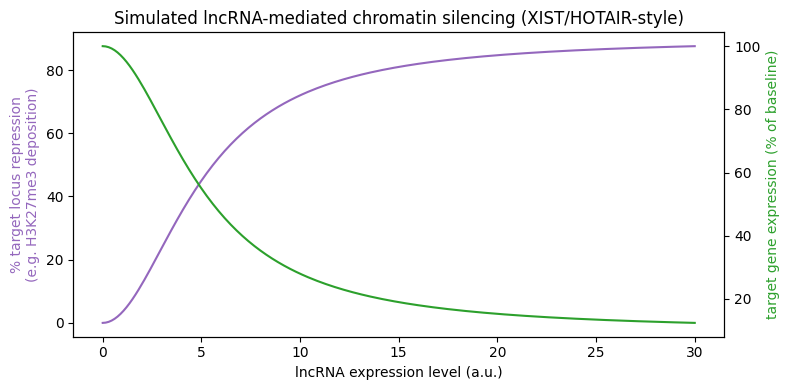

In [ ]:
def simulate_lncRNA_silencing(lncRNA_level, recruitment_Kd=5.0, hill=2.0,
                                max_repression=0.9):
    '''Simulate fractional repression of a target gene as a function of lncRNA expression level
    (a simple Hill-function model of complex recruitment -> repressive mark deposition).'''
    occupancy = lncRNA_level**hill / (recruitment_Kd**hill + lncRNA_level**hill)
    fractional_repression = max_repression * occupancy
    return fractional_repression

lncRNA_levels = np.linspace(0, 30, 200)
repression = simulate_lncRNA_silencing(lncRNA_levels)
target_gene_expr = 100 * (1 - repression)

fig, ax1 = plt.subplots()
ax1.plot(lncRNA_levels, repression*100, color='tab:purple')
ax1.set_xlabel('lncRNA expression level (a.u.)')
ax1.set_ylabel('% target locus repression\n(e.g. H3K27me3 deposition)', color='tab:purple')
ax2 = ax1.twinx()
ax2.plot(lncRNA_levels, target_gene_expr, color='tab:green')
ax2.set_ylabel('target gene expression (% of baseline)', color='tab:green')
plt.title('Simulated lncRNA-mediated chromatin silencing (XIST/HOTAIR-style)')
plt.tight_layout(); plt.show()


**Question 2.** At what approximate lncRNA expression level does the target gene lose ~50% of its expression? How does this relate to the `recruitment_Kd` parameter?


## Part 3 — ncRNA Expression as a Disease Biomarker: Cancer vs Normal

We'll simulate a small ncRNA expression dataset (e.g. from a miRNA-seq panel) across tumor and normal samples, run a differential expression test per ncRNA, and build a **volcano plot** to flag candidate cancer biomarkers.


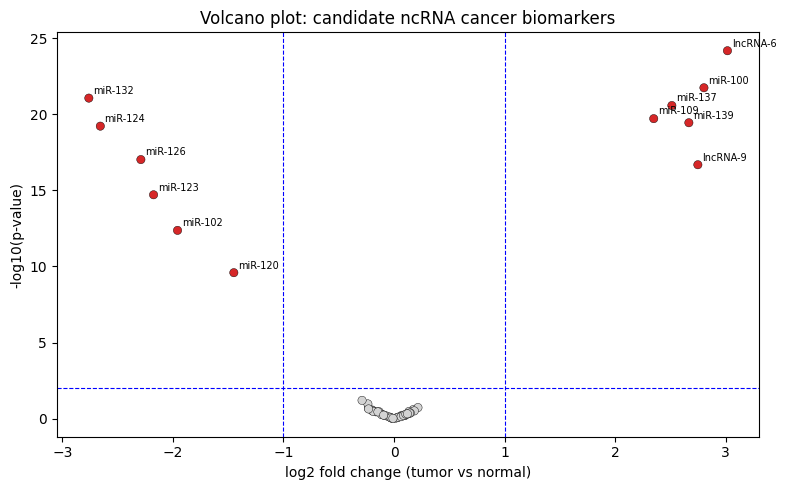

12 ncRNAs called significant (|log2FC|>1, p<0.01) — candidate biomarkers / drug targets.


,ncRNA,log2FC,p_value,neg_log10_p,significant
32,miR-132,-2.761151,8.634450e-22,21.063765,True
24,miR-124,-2.657161,6.014592e-20,19.220794,True
26,miR-126,-2.290309,9.446566e-18,17.024726,True
23,miR-123,-2.175437,1.941414e-15,14.711882,True
2,miR-102,-1.958643,4.246130e-13,12.372007,True
20,miR-120,-1.449249,2.557603e-10,9.592167,True
9,miR-109,2.349863,1.930291e-20,19.714377,True
37,miR-137,2.513971,2.656011e-21,20.575770,True
39,miR-139,2.667895,3.582422e-20,19.445823,True
49,lncRNA-9,2.749241,2.060296e-17,16.686070,True


In [ ]:
ncRNAs = [f"miR-{100+i}" for i in range(40)] + [f"lncRNA-{i}" for i in range(10)]
n_tumor, n_normal = 25, 25

# simulate baseline expression, then inject true differential expression for a subset
rng = np.random.default_rng(42)
baseline = rng.uniform(3, 10, size=len(ncRNAs))
true_lfc = np.zeros(len(ncRNAs))
up_idx = rng.choice(len(ncRNAs), 6, replace=False)
down_idx = rng.choice([i for i in range(len(ncRNAs)) if i not in up_idx], 6, replace=False)
true_lfc[up_idx] = rng.uniform(1.5, 3.5, 6)
true_lfc[down_idx] = -rng.uniform(1.5, 3.5, 6)

expr_normal = np.array([rng.normal(baseline[i], 0.6, n_normal) for i in range(len(ncRNAs))])
expr_tumor = np.array([rng.normal(baseline[i]+true_lfc[i], 0.6, n_tumor) for i in range(len(ncRNAs))])

results = []
for i, name in enumerate(ncRNAs):
    t_stat, p_val = stats.ttest_ind(expr_tumor[i], expr_normal[i])
    log2fc = expr_tumor[i].mean() - expr_normal[i].mean()
    results.append(dict(ncRNA=name, log2FC=log2fc, p_value=p_val))

de_df = pd.DataFrame(results)
de_df['neg_log10_p'] = -np.log10(de_df['p_value'])
de_df['significant'] = (de_df['p_value'] < 0.01) & (de_df['log2FC'].abs() > 1)

plt.figure(figsize=(8,5))
colors = de_df['significant'].map({True:'tab:red', False:'lightgray'})
plt.scatter(de_df['log2FC'], de_df['neg_log10_p'], c=colors, edgecolor='k', linewidth=0.3)
plt.axhline(-np.log10(0.01), color='blue', ls='--', linewidth=0.8)
plt.axvline(1, color='blue', ls='--', linewidth=0.8)
plt.axvline(-1, color='blue', ls='--', linewidth=0.8)
plt.xlabel('log2 fold change (tumor vs normal)')
plt.ylabel('-log10(p-value)')
plt.title('Volcano plot: candidate ncRNA cancer biomarkers')
for _, row in de_df[de_df['significant']].iterrows():
    plt.annotate(row['ncRNA'], (row['log2FC'], row['neg_log10_p']), fontsize=7,
                 xytext=(3,3), textcoords='offset points')
plt.tight_layout(); plt.show()

print(f"{de_df['significant'].sum()} ncRNAs called significant (|log2FC|>1, p<0.01) — candidate biomarkers / drug targets.")
de_df[de_df['significant']].sort_values('log2FC')


**Question 3.** Why do we require *both* a p-value cutoff **and** a fold-change cutoff, rather than just ranking by p-value alone?


## Part 4 — Building an ncRNA–mRNA Regulatory Network

Finally, we'll assemble a small **regulatory network graph**: miRNAs repressing target mRNAs, and an lncRNA acting as a **competing endogenous RNA (ceRNA)** / sponge that sequesters a miRNA away from its target — illustrating how ncRNAs act as network-level controllers, not just single-gene regulators.


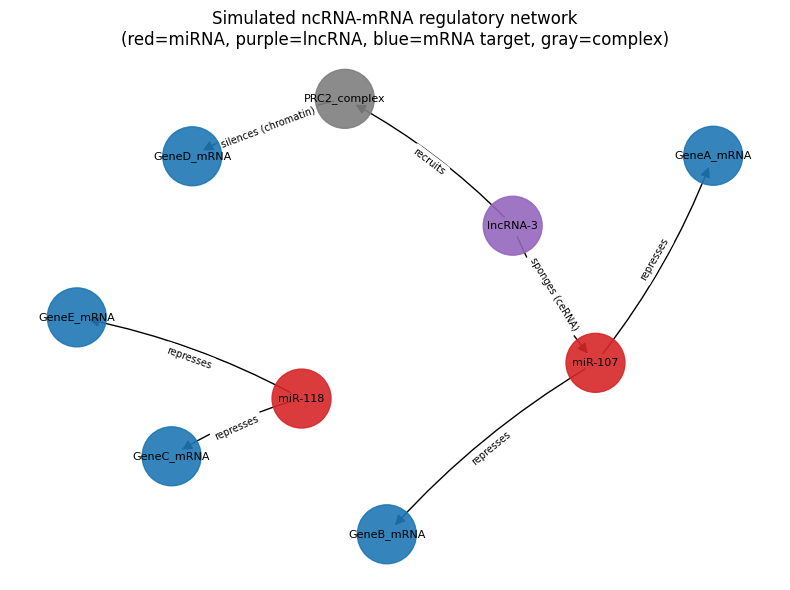

Network summary:
  miR-107 regulates 2 downstream node(s): ['GeneA_mRNA', 'GeneB_mRNA']
  miR-118 regulates 2 downstream node(s): ['GeneC_mRNA', 'GeneE_mRNA']
  lncRNA-3 regulates 2 downstream node(s): ['miR-107', 'PRC2_complex']
  PRC2_complex regulates 1 downstream node(s): ['GeneD_mRNA']


In [ ]:
import networkx as nx

G = nx.DiGraph()

# a few miRNAs repressing target mRNAs (from our significant hits above, illustrative mapping)
edges = [
    ("miR-107", "GeneA_mRNA", "represses"),
    ("miR-107", "GeneB_mRNA", "represses"),
    ("miR-118", "GeneC_mRNA", "represses"),
    ("lncRNA-3", "miR-107", "sponges (ceRNA)"),
    ("lncRNA-3", "PRC2_complex", "recruits"),
    ("PRC2_complex", "GeneD_mRNA", "silences (chromatin)"),
    ("miR-118", "GeneE_mRNA", "represses"),
]
for src, dst, rel in edges:
    G.add_edge(src, dst, relation=rel)

pos = nx.spring_layout(G, seed=4, k=1.1)
plt.figure(figsize=(8,6))
node_colors = []
for n in G.nodes():
    if n.startswith("miR"): node_colors.append('tab:red')
    elif n.startswith("lncRNA"): node_colors.append('tab:purple')
    elif "mRNA" in n: node_colors.append('tab:blue')
    else: node_colors.append('tab:gray')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15, connectionstyle='arc3,rad=0.08')
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title('Simulated ncRNA-mRNA regulatory network\n(red=miRNA, purple=lncRNA, blue=mRNA target, gray=complex)')
plt.axis('off'); plt.tight_layout(); plt.show()

print("Network summary:")
for node in G.nodes():
    out_deg = G.out_degree(node)
    if out_deg > 0:
        print(f"  {node} regulates {out_deg} downstream node(s): {list(G.successors(node))}")


**Question 4.** In this network, lncRNA-3 has an *indirect* effect on GeneA/GeneB expression (by sponging miR-107) in addition to its *direct* chromatin-silencing effect on GeneD. If lncRNA-3 were overexpressed in a tumor, what would you predict happens to GeneA/GeneB expression, and why might that make lncRNA-3 itself a drug target?


## Wrap-up Exercises

1. In Part 1, add a 5th simulated species ("piRNA", ~26–31 nt) with its own mean/sd and see how much it overlaps the tRNA-fragment class — what does that imply about length-only classification?
2. In Part 2, plot repression curves for two lncRNAs with different `recruitment_Kd` values on the same axes — which one is the more "potent" silencer at low expression?
3. In Part 3, increase `n_tumor`/`n_normal` sample size — how does that affect the number of ncRNAs called significant, for the same true effect sizes?
4. In Part 4, add a new edge representing a second lncRNA sponging miR-118, and re-draw the network. How does this change the “controller” role of miR-118?

---
*This notebook uses simulated/illustrative data for teaching purposes. For real analyses, substitute actual small-RNA-seq/microarray count data (e.g. from GEO/TCGA), real miRNA-target databases (miRTarBase, TargetScan), and real lncRNA-mechanism annotations (LNCipedia, RNAInter).*
